# Pulse of Prevention - Heart Disease Data EDA

## 1. Load & Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("heart.csv")
print("Raw shape:", df.shape)

# This dataset is a repeated/resampled version of the original 303-patient
# UCI Cleveland set - most rows are exact duplicates of the same patients.
df = df.drop_duplicates()
print("Unique patient records after dedup:", df.shape)

print("\nMissing values:\n", df.isnull().sum().sum(), "total")

Raw shape: (1025, 14)
Unique patient records after dedup: (302, 14)

Missing values:
 0 total


## 2. Basic Questions

**Average age of patients**

In [2]:
df["age"].mean().round(2)

np.float64(54.42)

**Gender distribution (1=male, 0=female)**

In [3]:
df["sex"].value_counts()

sex
1    206
0     96
Name: count, dtype: int64

**Average resting blood pressure**

In [4]:
df["trestbps"].mean().round(2)

np.float64(131.6)

**Patients with fasting blood sugar > 120 mg/dl**

In [5]:
df["fbs"].sum()

np.int64(45)

**Chest pain types present**

In [6]:
sorted(df["cp"].unique())

[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

**Maximum heart rate achieved (dataset-wide)**

In [7]:
df["thalach"].max()

np.int64(202)

**% of patients with exercise-induced angina**

In [8]:
(df["exang"].mean() * 100).round(2)

np.float64(32.78)

**Average cholesterol level**

In [9]:
df["chol"].mean().round(2)

np.float64(246.5)

**Patients with resting ECG result = 2**

In [10]:
(df["restecg"] == 2).sum()

np.int64(4)

**Distribution of major vessels (ca)**

In [11]:
df["ca"].value_counts().sort_index()

ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

## 3. Medium Questions

**Correlation between age and cholesterol**

In [12]:
df[["age", "chol"]].corr()

,age,chol
age,1.000000,0.207216
chol,0.207216,1.000000


**Chest pain type distribution by age group**

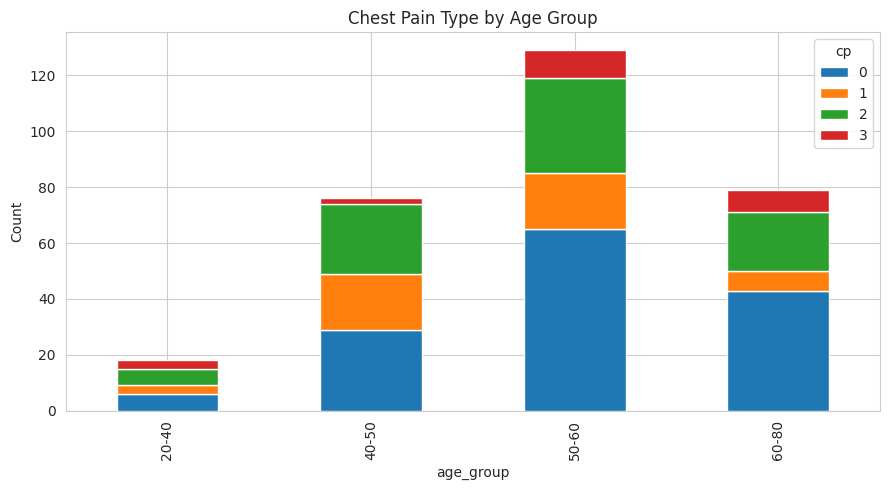

In [13]:
df["age_group"] = pd.cut(df["age"], bins=[20, 40, 50, 60, 80],
                          labels=["20-40", "40-50", "50-60", "60-80"])
age_cp = df.groupby("age_group", observed=True)["cp"].value_counts().unstack()
age_cp.plot(kind="bar", stacked=True, figsize=(9, 5))
plt.title("Chest Pain Type by Age Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

**Max heart rate: with vs without exercise-induced angina**

In [14]:
df.groupby("exang")["thalach"].mean().round(2)

exang
0    155.60
1    137.21
Name: thalach, dtype: float64

**Resting blood pressure: male vs female**

In [15]:
df.groupby("sex")["trestbps"].mean().round(2)

sex
0    133.08
1    130.91
Name: trestbps, dtype: float64

**Fasting blood sugar vs heart disease presence**

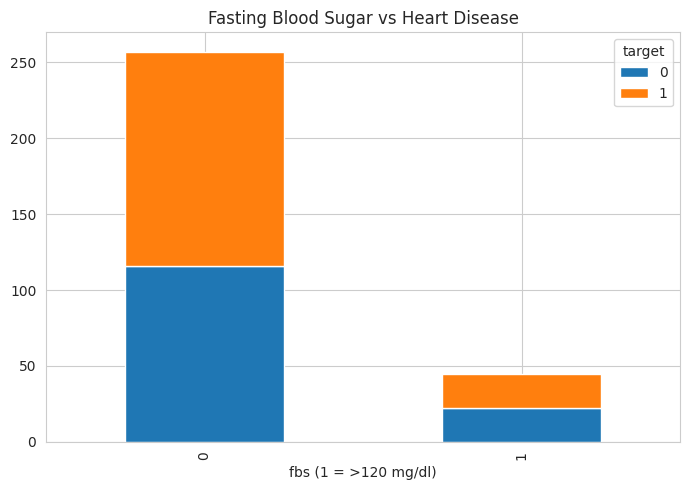

In [16]:
pd.crosstab(df["fbs"], df["target"]).plot(kind="bar", stacked=True, figsize=(7, 5))
plt.title("Fasting Blood Sugar vs Heart Disease")
plt.xlabel("fbs (1 = >120 mg/dl)")
plt.tight_layout()
plt.show()

**Major vessels (ca) vs heart disease presence**

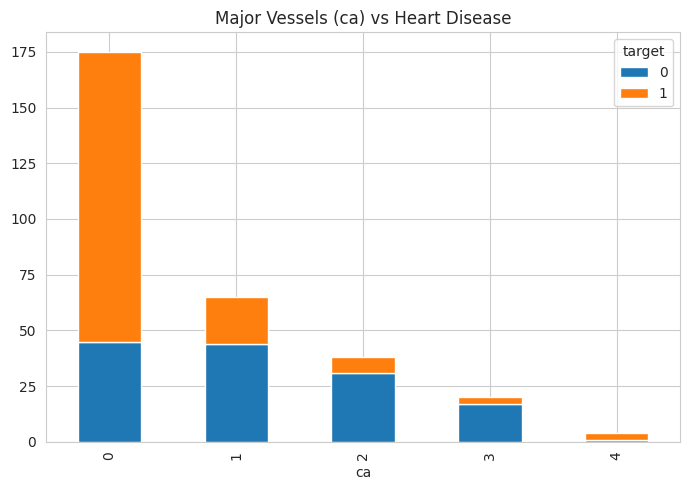

In [17]:
pd.crosstab(df["ca"], df["target"]).plot(kind="bar", stacked=True, figsize=(7, 5))
plt.title("Major Vessels (ca) vs Heart Disease")
plt.tight_layout()
plt.show()

**Average oldpeak by chest pain type**

In [18]:
df.groupby("cp")["oldpeak"].mean().round(2)

cp
0    1.38
1    0.32
2    0.81
3    1.39
Name: oldpeak, dtype: float64

**Thalassemia type distribution among heart disease patients**

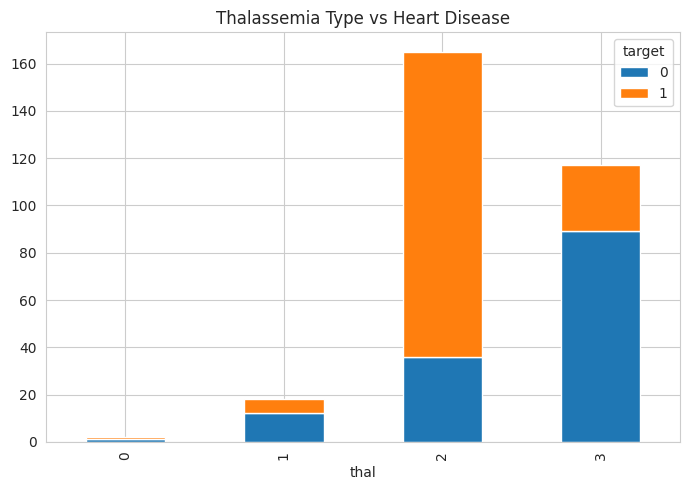

In [19]:
pd.crosstab(df["thal"], df["target"]).plot(kind="bar", stacked=True, figsize=(7, 5))
plt.title("Thalassemia Type vs Heart Disease")
plt.tight_layout()
plt.show()

**Most common risk factor combinations in heart disease patients**

In [20]:
(df[df["target"] == 1]
   .groupby(["cp", "fbs", "exang", "thal"])
   .size()
   .reset_index(name="count")
   .sort_values("count", ascending=False)
   .head(10))

,cp,fbs,exang,thal,count
15,2,0,0,2,41
8,1,0,0,2,30
1,0,0,0,2,23
19,2,1,0,2,10
4,0,0,1,2,6
16,2,0,0,3,6
23,3,0,0,2,5
9,1,0,0,3,4
17,2,0,1,2,4
20,2,1,0,3,3


**Pairwise comparison: patients with vs without heart disease**

In [21]:
compare_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
comparison = df.groupby("target")[compare_cols].mean().round(2)
comparison.index = ["No Heart Disease", "Heart Disease"]
comparison

,age,trestbps,chol,thalach,oldpeak
No Heart Disease,56.60,134.40,251.09,139.10,1.59
Heart Disease,52.59,129.25,242.64,158.38,0.59


## 4. Advanced Questions

*Advanced Q3 (logistic regression) dropped - needs sklearn, out of pandas/numpy/matplotlib scope. Advanced Q5 ("survival rates over a period") dropped - this dataset is a single snapshot per patient with no follow-up/time data, so it cannot be answered from what's available.*

**Combined effect of age, cholesterol, blood pressure on heart disease**

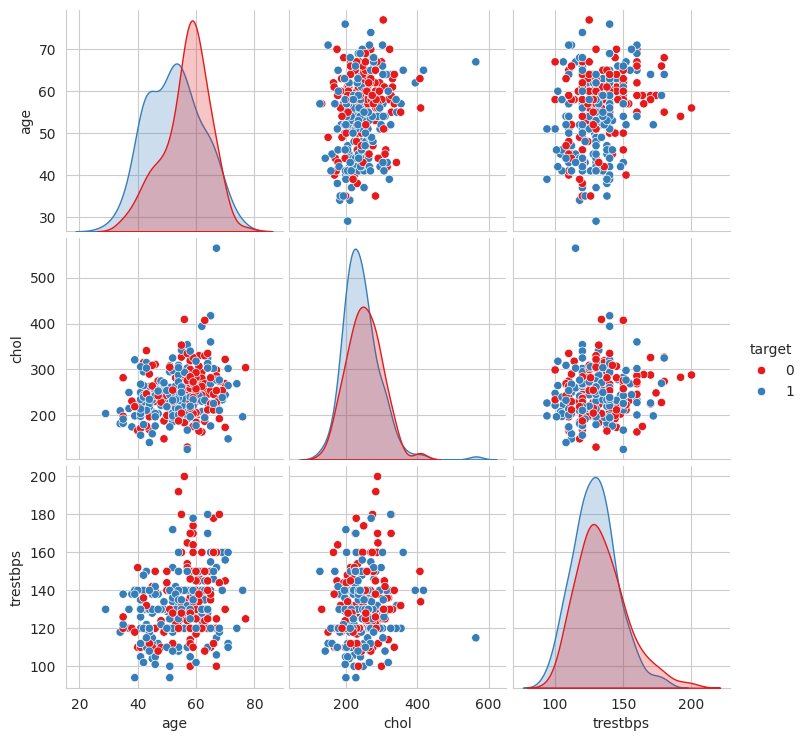

In [22]:
sns.pairplot(df, hue="target", vars=["age", "chol", "trestbps"], palette="Set1")
plt.show()

**Clinical measurement most correlated with heart disease presence**

In [23]:
df.corr(numeric_only=True)["target"].sort_values(ascending=False)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64

**ST segment slope by chest pain type**

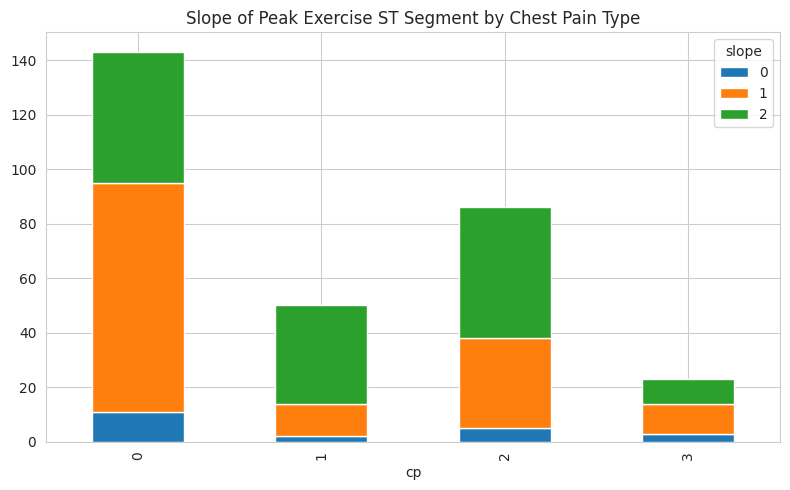

In [24]:
df.groupby("cp")["slope"].value_counts().unstack().plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Slope of Peak Exercise ST Segment by Chest Pain Type")
plt.tight_layout()
plt.show()